# Loading dataframe and defining features and target

In [4]:
from __future__ import print_function, division   # Ensures Python3 printing & division standard
import pandas as pd 
from pandas import Series, DataFrame 
from matplotlib import pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.metrics import confusion_matrix
import lightgbm as lgb
from lightgbm import early_stopping
import time
import shap
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from tqdm.notebook import tqdm
from matplotlib import pyplot as plt
import warnings
warnings.filterwarnings("ignore")

SavePlots = False

data = pd.DataFrame(np.genfromtxt('data_mice_encoded.csv', delimiter=',', names=True))
data = data[data['CLAIM_COUNT'] == 1]

target = 'CLAIM_SIZE_INDEX'

features = [
    col for col in data.columns
    if col not in ['CLAIM_COUNT', 'CLAIM_SIZE', 'CLAIM_SIZE_INDEX', 
                   'POLICY', 'EXPOSURE', 'OUTER_WALLS', 'HEATING_TYPE', 
                   'WATER_SUPPLY_TYPE', 'ROOF_TYPE']
]

X = data[features]
y = data[target]

feature_names = np.array(X.columns)


# Feature ranking based on split, gain, SHAP and permutation

In [ ]:
from __future__ import print_function, division

import os
import sys
import contextlib

from sklearn.model_selection import KFold


warnings.filterwarnings("ignore")

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=582
)

# multiple seeds for robustness
seeds = list(range(20))

# coarse hyperparameter grid
param_grid = [

    # small trees
    {"num_leaves": 6,  "learning_rate": 0.03},
    {"num_leaves": 6,  "learning_rate": 0.05},
    {"num_leaves": 6,  "learning_rate": 0.10},

    # medium-small trees
    {"num_leaves": 10, "learning_rate": 0.03},
    {"num_leaves": 10, "learning_rate": 0.05},
    {"num_leaves": 10, "learning_rate": 0.10},

    # medium trees
    {"num_leaves": 15, "learning_rate": 0.03},
    {"num_leaves": 15, "learning_rate": 0.05},
    {"num_leaves": 15, "learning_rate": 0.10},

    # larger trees
    {"num_leaves": 25, "learning_rate": 0.03},
    {"num_leaves": 25, "learning_rate": 0.05},
    {"num_leaves": 25, "learning_rate": 0.10},
]

@contextlib.contextmanager
def suppress_stdout():
    with open(os.devnull, "w") as f:
        old_stdout = sys.stdout
        sys.stdout = f
        try:
            yield
        finally:
            sys.stdout = old_stdout


def train_lgb(X_train, y_train, X_val, y_val, params, seed):

    lgb_params = {
        "objective": "regression",
        "metric": "rmse",
        "boosting_type": "gbdt",
        "num_leaves": params["num_leaves"],
        "learning_rate": params["learning_rate"],
        "verbosity": -1,
        "seed": seed
    }

    lgb_train = lgb.Dataset(X_train, y_train)
    lgb_eval = lgb.Dataset(X_val, y_val, reference=lgb_train)

    with suppress_stdout():

        gbm = lgb.train(
            lgb_params,
            lgb_train,
            num_boost_round=1000,
            valid_sets=[lgb_eval],
            callbacks=[lgb.early_stopping(20)]
        )

    return gbm

split_scores = []
gain_scores = []
perm_scores = []
shap_scores = []

# stability tracker
topk_hits = {f: 0 for f in feature_names}
total_runs = 0


for params in tqdm(param_grid, desc="Hyperparameters"):

    for seed in tqdm(seeds, desc="Seeds", leave=False):

        for fold, (train_idx, test_idx) in enumerate(
            tqdm(
                kf.split(X),
                total=kf.get_n_splits(),
                desc="CV folds",
                leave=False
            ),
            start=1
        ):


            X_train = X.iloc[train_idx]
            X_test  = X.iloc[test_idx]

            y_train = y.iloc[train_idx]
            y_test  = y.iloc[test_idx]

            gbm = train_lgb(
                X_train,
                y_train,
                X_test,
                y_test,
                params,
                seed
            )

            perm_model = lgb.LGBMRegressor(
                objective="regression",
                num_leaves=params["num_leaves"],
                learning_rate=params["learning_rate"],
                n_estimators=(
                    gbm.best_iteration
                    if gbm.best_iteration
                    else 500
                ),
                random_state=seed,
                verbosity=-1
            )

            with suppress_stdout():
                perm_model.fit(X_train, y_train)

            perm = permutation_importance(
                perm_model,
                X_test,
                y_test,
                n_repeats=5,
                random_state=seed + fold,
                n_jobs=-1
            )

            perm_scores.append(
                perm.importances_mean
            )

            split_scores.append(
                gbm.feature_importance(
                    importance_type="split"
                )
            )

            gain_scores.append(
                gbm.feature_importance(
                    importance_type="gain"
                )
            )

            explainer = shap.TreeExplainer(gbm)

            shap_values = explainer.shap_values(X_test)

            shap_scores.append(
                np.abs(shap_values).mean(axis=0)
            )

            importances = perm.importances_mean

            topk_idx = np.argsort(importances)[-10:]

            for idx in topk_idx:
                topk_hits[feature_names[idx]] += 1

            total_runs += 1


split_mean = np.mean(split_scores, axis=0)
gain_mean  = np.mean(gain_scores, axis=0)
perm_mean  = np.mean(perm_scores, axis=0)
shap_mean  = np.mean(shap_scores, axis=0)

final = pd.DataFrame({
    "feature": feature_names,
    "split": split_mean,
    "gain": gain_mean,
    "perm": perm_mean,
    "shap": shap_mean
})


for col in ["split", "gain", "perm", "shap"]:

    final[col + "_rank"] = (
        final[col]
        .rank(ascending=False)
    )


final["total_rank"] = (
    final["split_rank"] +
    final["gain_rank"] +
    final["perm_rank"] +
    final["shap_rank"]
)


final["stability"] = final["feature"].map(
    lambda f: topk_hits[f] / total_runs
)


final["final_score"] = (
    final["total_rank"]
    - final["stability"] * len(final)
)


final_sorted = final.sort_values("final_score")

In [17]:
print(final_sorted.head(20))

                                         feature      split          gain  \
2                              CONSTRUCTION_YEAR  48.450000  5.109459e+13   
9                                     HOUDEN10KM  35.533333  2.859533e+13   
1                                     DEDUCTIBLE  27.383333  1.869192e+13   
6                               RESIDENTIAL_AREA  60.683333  4.413575e+13   
20                   ROOF_TYPE_CAT_Thatched_Roof  13.533333  3.403298e+13   
3                                      BUILDINGS  10.916667  1.139177e+13   
25    WATER_SUPPLY_TYPE_CAT_Private_Water_Supply   8.450000  1.452068e+13   
7                                  BASEMENT_AREA   7.916667  6.250821e+12   
39                   OUTER_WALLS_CAT_Brick_Walls   4.150000  5.177177e+12   
27  WATER_SUPPLY_TYPE_CAT_Water_Extraction_Plant   1.816667  6.851735e+11   
47                OUTER_WALLS_CAT_Timber_Framing   1.766667  1.572944e+12   
29   HEATING_TYPE_CAT_Central_Heating_Own_System   2.016667  2.095037e+12   

# Checking for correlation between features

<Axes: >

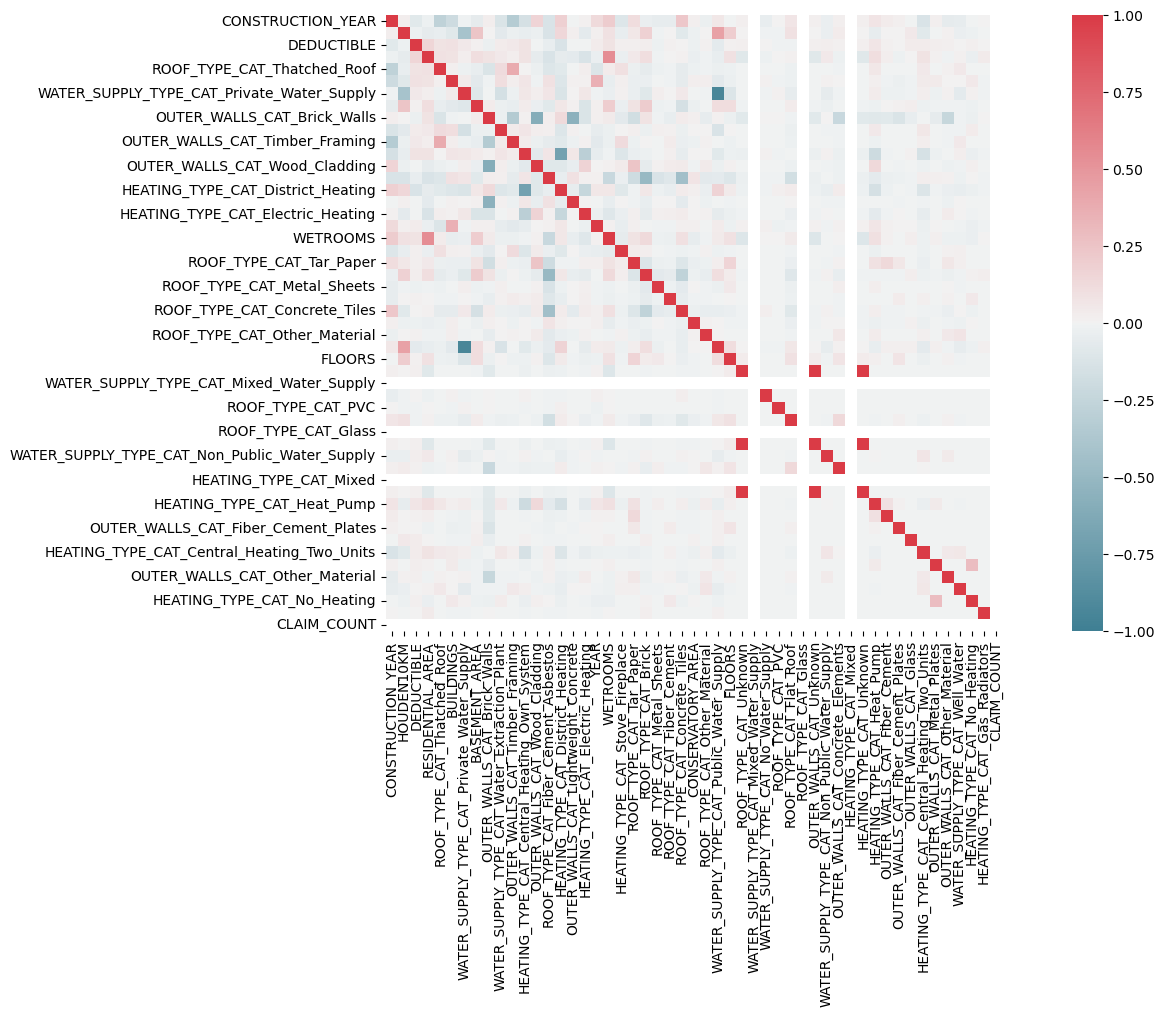

In [15]:
import seaborn as sns

data_selected = data[final_sorted["feature"].tolist() + ["CLAIM_COUNT"]]

fig, ax = plt.subplots(1, 1, figsize=(18, 8))
sns.heatmap(data_selected.corr(), mask=np.zeros_like(data_selected.corr(), dtype=bool),
            cmap=sns.diverging_palette(220, 10, as_cmap=True), vmin=-1.0, vmax=1.0,
            square=True)

In [20]:
corr = data_selected.corr()

threshold = 0.5

corr_pairs = []

for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        val = corr.iloc[i, j]
        if abs(val) >= threshold:
            corr_pairs.append((corr.columns[i], corr.columns[j], val))

corr_pairs = sorted(corr_pairs, key=lambda x: abs(x[2]), reverse=True)

corr_df = pd.DataFrame(corr_pairs, columns=["feature_1", "feature_2", "corr"])

importance_lookup = dict(zip(
    final_sorted["feature"],
    final_sorted["total_rank"]  
))

results = []

for f1, f2, corr_val in corr_pairs:
    
    score1 = importance_lookup.get(f1, np.nan)
    score2 = importance_lookup.get(f2, np.nan)
    
    # lower rank sum = more important
    if score1 < score2:
        keep = f1
        drop = f2
    else:
        keep = f2
        drop = f1
    
    results.append((f1, f2, corr_val, keep, drop))

corr_ranked_df = pd.DataFrame(
    results,
    columns=["feature_1", "feature_2", "corr", "keep", "drop"]
)

print(corr_ranked_df)

                                     feature_1  \
0                        ROOF_TYPE_CAT_Unknown   
1                        ROOF_TYPE_CAT_Unknown   
2                      OUTER_WALLS_CAT_Unknown   
3   WATER_SUPPLY_TYPE_CAT_Private_Water_Supply   
4  HEATING_TYPE_CAT_Central_Heating_Own_System   
5                  OUTER_WALLS_CAT_Brick_Walls   
6                  OUTER_WALLS_CAT_Brick_Walls   
7                             RESIDENTIAL_AREA   

                                   feature_2      corr  \
0                    OUTER_WALLS_CAT_Unknown  1.000000   
1                   HEATING_TYPE_CAT_Unknown  1.000000   
2                   HEATING_TYPE_CAT_Unknown  1.000000   
3  WATER_SUPPLY_TYPE_CAT_Public_Water_Supply -0.943861   
4          HEATING_TYPE_CAT_District_Heating -0.700817   
5              OUTER_WALLS_CAT_Wood_Cladding -0.598944   
6       OUTER_WALLS_CAT_Lightweight_Concrete -0.555755   
7                                   WETROOMS  0.543744   

                          